# Activity 02: House Prices (Regression)

**Objective:** Prepare a dataset for a regression model that predicts house sale prices.

**Dataset:** House Prices dataset (Ames, Iowa housing data / Kaggle) — 1,460 residential properties described by
79 explanatory attributes, plus an `Id` column and the target variable `SalePrice`.


## 1. Load and explore the data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')

# Loading the dataset from the shared data-science/datasets folder
df = pd.read_csv('../../datasets/house_prices.csv')

print('Dataset shape (rows, columns):', df.shape)
df.head()


Dataset shape (rows, columns): (1460, 81)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [2]:
# General information: columns, data types and non-null counts
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

In [3]:
# Descriptive statistics for the numeric columns
df.describe().T


,count,mean,std,min,25%,50%,75%,max
Id,1460.0,730.500000,421.610009,1.0,365.75,730.5,1095.25,1460.0
MSSubClass,1460.0,56.897260,42.300571,20.0,20.00,50.0,70.00,190.0
LotFrontage,1201.0,70.049958,24.284752,21.0,59.00,69.0,80.00,313.0
LotArea,1460.0,10516.828082,9981.264932,1300.0,7553.50,9478.5,11601.50,215245.0
OverallQual,1460.0,6.099315,1.382997,1.0,5.00,6.0,7.00,10.0
OverallCond,1460.0,5.575342,1.112799,1.0,5.00,5.0,6.00,9.0
YearBuilt,1460.0,1971.267808,30.202904,1872.0,1954.00,1973.0,2000.00,2010.0
YearRemodAdd,1460.0,1984.865753,20.645407,1950.0,1967.00,1994.0,2004.00,2010.0
MasVnrArea,1452.0,103.685262,181.066207,0.0,0.00,0.0,166.00,1600.0
BsmtFinSF1,1460.0,443.639726,456.098091,0.0,0.00,383.5,712.25,5644.0


SalePrice summary statistics:
count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64


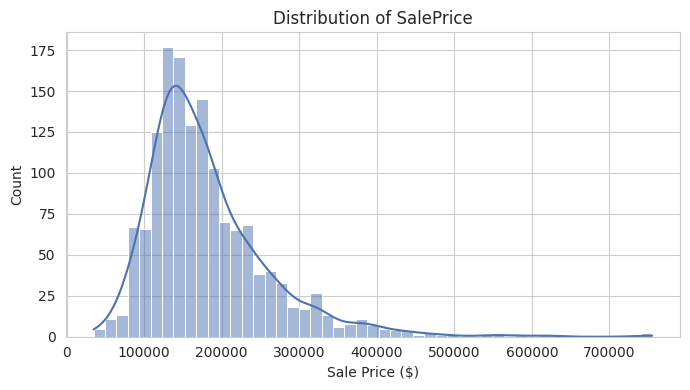

In [4]:
# Quick look at the target variable
print('SalePrice summary statistics:')
print(df['SalePrice'].describe())

plt.figure(figsize=(7, 4))
sns.histplot(df['SalePrice'], kde=True, color='#4C72B0')
plt.title('Distribution of SalePrice')
plt.xlabel('Sale Price ($)')
plt.tight_layout()
plt.show()


## 2. Remove irrelevant attributes

The `Id` column is a unique record identifier: it carries no predictive information about the sale price and
would only add noise (or even leak spurious correlations) if kept in the model. It is therefore removed.

All other 79 attributes describe some physical, locational, or transactional aspect of the property (lot size,
quality ratings, areas, year built, sale conditions, etc.) and are potentially informative, so none of them are
dropped at this stage purely for "irrelevance".


In [5]:
# Confirm Id is indeed a unique identifier (no duplicates, sequential range)
print('Number of unique Id values:', df['Id'].nunique(), 'out of', len(df), 'rows')

# Drop the identifier column
df = df.drop(columns=['Id'])
print('New shape after removing Id:', df.shape)


Number of unique Id values: 1460 out of 1460 rows
New shape after removing Id: (1460, 80)


## 3. Handling missing data

Let's list every attribute that has missing values and how many, then apply an appropriate imputation strategy
for each type of column:

- **Categorical columns where `NaN` means "feature not present"** (e.g. `PoolQC`, `Alley`, `Fence`,
  `FireplaceQu`, `GarageType`, `BsmtQual`, `MasVnrType`, etc. — confirmed by the dataset's data dictionary):
  filled with the label `'None'`.
- **Numeric columns where `NaN` means "feature not present"** (e.g. `GarageYrBlt`, `MasVnrArea`): filled with `0`.
- **`LotFrontage`** (linear feet of street connected to the property): filled with the **median LotFrontage of
  the same `Neighborhood`**, since lot frontage strongly depends on the neighborhood's typical lot layout.
- **`Electrical`** (only 1 missing value, a genuinely missing data point, not an absent feature): filled with the
  **mode** (most frequent category).


In [6]:
# List all attributes with missing values, sorted from most to least missing
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)

missing_table = pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})
print(f'Number of attributes with missing values: {len(missing_table)}')
missing_table


Number of attributes with missing values: 19


,missing_count,missing_pct
PoolQC,1453,99.52
MiscFeature,1406,96.30
Alley,1369,93.77
Fence,1179,80.75
MasVnrType,872,59.73
FireplaceQu,690,47.26
LotFrontage,259,17.74
GarageType,81,5.55
GarageYrBlt,81,5.55
GarageFinish,81,5.55


In [7]:
# Columns where NaN means the feature is simply absent from the property
none_categorical_cols = ['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu',
                          'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
                          'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
                          'MasVnrType']

for c in none_categorical_cols:
    df[c] = df[c].fillna('None')

# Numeric columns where NaN means the corresponding feature does not exist
zero_numeric_cols = ['GarageYrBlt', 'MasVnrArea']
for c in zero_numeric_cols:
    df[c] = df[c].fillna(0)

print('Missing values remaining after these two imputations:')
print(df.isnull().sum().sort_values(ascending=False).head(10))


Missing values remaining after these two imputations:
LotFrontage    259
Electrical       1
MSZoning         0
MSSubClass       0
Street           0
Alley            0
LotShape         0
LotArea          0
Utilities        0
LotConfig        0
dtype: int64


In [8]:
# LotFrontage: impute with the median LotFrontage of the same Neighborhood
df['LotFrontage'] = df.groupby('Neighborhood')['LotFrontage'].transform(
    lambda x: x.fillna(x.median())
)

# Electrical: only 1 missing value -> impute with the mode
df['Electrical'] = df['Electrical'].fillna(df['Electrical'].mode()[0])

print('Total missing values remaining in the dataset:', df.isnull().sum().sum())


Total missing values remaining in the dataset: 0


**Conclusion:** after these imputations, the dataset has zero remaining missing values.

## 4. Converting categorical variables to numeric

Categorical attributes fall into two groups, handled differently:

- **Ordinal (quality/condition) attributes**, whose categories have a natural order
  (`Po` < `Fa` < `TA` < `Gd` < `Ex`): converted with **label encoding**, mapping each category to an integer
  that preserves the quality ranking.
- **Nominal attributes**, whose categories have no inherent order (e.g. `Neighborhood`, `MSZoning`,
  `RoofStyle`): converted with **one-hot encoding**, creating one binary column per category.


In [9]:
# Ordinal quality/condition columns and their natural ranking
quality_scale = {'None': 0, 'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5}
ordinal_columns = ['ExterQual', 'ExterCond', 'BsmtQual', 'BsmtCond', 'HeatingQC',
                    'KitchenQual', 'FireplaceQu', 'GarageQual', 'GarageCond', 'PoolQC']

for c in ordinal_columns:
    df[c] = df[c].map(quality_scale)

print('Example of label-encoded ordinal columns:')
df[ordinal_columns].head()


Example of label-encoded ordinal columns:


,ExterQual,ExterCond,BsmtQual,BsmtCond,HeatingQC,KitchenQual,FireplaceQu,GarageQual,GarageCond,PoolQC
0,4,3,4,3,5,4,0,3,3,0
1,3,3,4,3,5,3,3,3,3,0
2,4,3,4,3,5,4,3,3,3,0
3,3,3,3,4,4,4,4,3,3,0
4,4,3,4,3,5,4,3,3,3,0


In [10]:
# Remaining categorical (nominal) columns
nominal_columns = df.select_dtypes(include='object').columns.tolist()
print(f'Number of nominal columns to one-hot encode: {len(nominal_columns)}')
print(nominal_columns)


Number of nominal columns to one-hot encode: 33
['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'Foundation', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'CentralAir', 'Electrical', 'Functional', 'GarageType', 'GarageFinish', 'PavedDrive', 'Fence', 'MiscFeature', 'SaleType', 'SaleCondition']


/tmp/ipykernel_541/628191525.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  nominal_columns = df.select_dtypes(include='object').columns.tolist()


In [11]:
# One-hot encoding of the remaining nominal categorical columns
df_encoded = pd.get_dummies(df, columns=nominal_columns, drop_first=True)

print('Shape before one-hot encoding:', df.shape)
print('Shape after one-hot encoding:', df_encoded.shape)
df_encoded.head()


Shape before one-hot encoding: (1460, 80)
Shape after one-hot encoding: (1460, 230)


,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,ExterQual,ExterCond,BsmtQual,BsmtCond,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,HeatingQC,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Fireplaces,FireplaceQu,GarageYrBlt,GarageCars,GarageArea,GarageQual,GarageCond,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,MiscVal,MoSold,YrSold,SalePrice,MSZoning_FV,MSZoning_RH,MSZoning_RL,MSZoning_RM,Street_Pave,Alley_None,Alley_Pave,LotShape_IR2,LotShape_IR3,LotShape_Reg,LandContour_HLS,LandContour_Low,LandContour_Lvl,Utilities_NoSeWa,LotConfig_CulDSac,LotConfig_FR2,LotConfig_FR3,LotConfig_Inside,LandSlope_Mod,LandSlope_Sev,Neighborhood_Blueste,Neighborhood_BrDale,Neighborhood_BrkSide,Neighborhood_ClearCr,Neighborhood_CollgCr,Neighborhood_Crawfor,Neighborhood_Edwards,Neighborhood_Gilbert,Neighborhood_IDOTRR,Neighborhood_MeadowV,Neighborhood_Mitchel,Neighborhood_NAmes,Neighborhood_NPkVill,Neighborhood_NWAmes,Neighborhood_NoRidge,Neighborhood_NridgHt,Neighborhood_OldTown,Neighborhood_SWISU,Neighborhood_Sawyer,Neighborhood_SawyerW,Neighborhood_Somerst,Neighborhood_StoneBr,Neighborhood_Timber,Neighborhood_Veenker,Condition1_Feedr,Condition1_Norm,Condition1_PosA,Condition1_PosN,Condition1_RRAe,Condition1_RRAn,Condition1_RRNe,Condition1_RRNn,Condition2_Feedr,Condition2_Norm,Condition2_PosA,Condition2_PosN,Condition2_RRAe,Condition2_RRAn,Condition2_RRNn,BldgType_2fmCon,BldgType_Duplex,BldgType_Twnhs,BldgType_TwnhsE,HouseStyle_1.5Unf,HouseStyle_1Story,HouseStyle_2.5Fin,HouseStyle_2.5Unf,HouseStyle_2Story,HouseStyle_SFoyer,HouseStyle_SLvl,RoofStyle_Gable,RoofStyle_Gambrel,RoofStyle_Hip,RoofStyle_Mansard,RoofStyle_Shed,RoofMatl_CompShg,RoofMatl_Membran,RoofMatl_Metal,RoofMatl_Roll,RoofMatl_Tar&Grv,RoofMatl_WdShake,RoofMatl_WdShngl,Exterior1st_AsphShn,Exterior1st_BrkComm,Exterior1st_BrkFace,Exterior1st_CBlock,Exterior1st_CemntBd,Exterior1st_HdBoard,Exterior1st_ImStucc,Exterior1st_MetalSd,Exterior1st_Plywood,Exterior1st_Stone,Exterior1st_Stucco,Exterior1st_VinylSd,Exterior1st_Wd Sdng,Exterior1st_WdShing,Exterior2nd_AsphShn,Exterior2nd_Brk Cmn,Exterior2nd_BrkFace,Exterior2nd_CBlock,Exterior2nd_CmentBd,Exterior2nd_HdBoard,Exterior2nd_ImStucc,Exterior2nd_MetalSd,Exterior2nd_Other,Exterior2nd_Plywood,Exterior2nd_Stone,Exterior2nd_Stucco,Exterior2nd_VinylSd,Exterior2nd_Wd Sdng,Exterior2nd_Wd Shng,MasVnrType_BrkFace,MasVnrType_None,MasVnrType_Stone,Foundation_CBlock,Foundation_PConc,Foundation_Slab,Foundation_Stone,Foundation_Wood,BsmtExposure_Gd,BsmtExposure_Mn,BsmtExposure_No,BsmtExposure_None,BsmtFinType1_BLQ,BsmtFinType1_GLQ,BsmtFinType1_LwQ,BsmtFinType1_None,BsmtFinType1_Rec,BsmtFinType1_Unf,BsmtFinType2_BLQ,BsmtFinType2_GLQ,BsmtFinType2_LwQ,BsmtFinType2_None,BsmtFinType2_Rec,BsmtFinType2_Unf,Heating_GasA,Heating_GasW,Heating_Grav,Heating_OthW,Heating_Wall,CentralAir_Y,Electrical_FuseF,Electrical_FuseP,Electrical_Mix,Electrical_SBrkr,Functional_Maj2,Functional_Min1,Functional_Min2,Functional_Mod,Functional_Sev,Functional_Typ,GarageType_Attchd,GarageType_Basment,GarageType_BuiltIn,GarageType_CarPort,GarageType_Detchd,GarageType_None,GarageFinish_None,GarageFinish_RFn,GarageFinish_Unf,PavedDrive_P,PavedDrive_Y,Fence_GdWo,Fence_MnPrv,Fence_MnWw,Fence_None,MiscFeature_None,MiscFeature_Othr,MiscFeature_Shed,MiscFeature_TenC,SaleType_CWD,SaleType_Con,SaleType_ConLD,SaleType_ConLI,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
0,60,65.0,8450,7,5,2003,2003,196.0,4,3,4,3,706,0,150,856,5,856,854,0,1710,1,0,2,1,3,1,4,8,0,0,2003.0,2,548,3,3,0,61,0,0,0,0,0,0,2,2008,208500,False,False,True,False,True,True,False,False,False,True,False,False,True,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,

**Note:** `drop_first=True` drops one dummy category per attribute to avoid multicollinearity (the "dummy
variable trap"), since that category's information is already implicit when all other dummies are 0.


## 5. Data standardization

Finally, we standardize (z-score) three continuous attributes with very different scales and strong right-skew:
`LotArea`, `GrLivArea`, and `GarageArea`. `StandardScaler` transforms each variable to have mean 0 and standard
deviation 1, which helps distance-based and gradient-based regression algorithms (e.g. linear/ridge/lasso
regression, SVR, neural networks) converge faster and treat all features on a comparable scale.


In [12]:
continuous_columns = ['LotArea', 'GrLivArea', 'GarageArea']

print('Statistics BEFORE standardization:')
display(df_encoded[continuous_columns].describe().T[['min', 'max', 'mean', 'std']])

scaler = StandardScaler()
df_encoded[continuous_columns] = scaler.fit_transform(df_encoded[continuous_columns])

print('\nStatistics AFTER standardization (expected: mean≈0, std≈1):')
display(df_encoded[continuous_columns].describe().T[['min', 'max', 'mean', 'std']])


Statistics BEFORE standardization:


,min,max,mean,std
LotArea,1300.0,215245.0,10516.828082,9981.264932
GrLivArea,334.0,5642.0,1515.463699,525.480383
GarageArea,0.0,1418.0,472.980137,213.804841



Statistics AFTER standardization (expected: mean≈0, std≈1):


,min,max,mean,std
LotArea,-0.923729,20.518273,-5.840077e-17,1.000343
GrLivArea,-2.249120,7.855574,-1.277517e-16,1.000343
GarageArea,-2.212963,4.421526,-1.216683e-17,1.000343


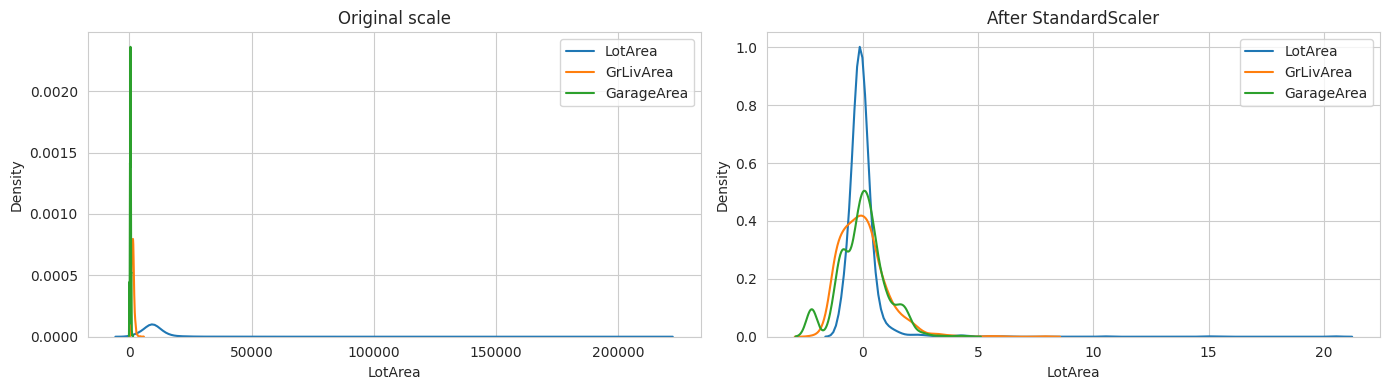

In [13]:
# Visual comparison of the effect of standardization
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for col in continuous_columns:
    sns.kdeplot(df[col], ax=axes[0], label=col)
axes[0].set_title('Original scale')
axes[0].legend()

for col in continuous_columns:
    sns.kdeplot(df_encoded[col], ax=axes[1], label=col)
axes[1].set_title('After StandardScaler')
axes[1].legend()

plt.tight_layout()
plt.show()


### Summary

The dataset is now fully preprocessed and ready to be used in a regression model:

1. The irrelevant `Id` column was removed.
2. All missing values were treated with an imputation strategy appropriate to what each `NaN` actually means
   (absent feature vs. genuinely missing data).
3. All categorical variables were converted to numeric form (ordinal → label encoding, nominal → one-hot
   encoding).
4. The continuous attributes `LotArea`, `GrLivArea`, and `GarageArea` were standardized with `StandardScaler`.

The resulting `df_encoded` DataFrame, together with the target `SalePrice`, is ready for training a regression
model (e.g. Linear Regression, Ridge, Random Forest, Gradient Boosting).
